# ICMS 150 (June 1 experiment)

- Closed loop plan: day 1: perform visual (16 orientations, 100 trials) and electrical (3000 patterns, 50 oracles x 20 trials). This notebook is used after output spike sorting and curation to fit stimulus-encoder TCN model and generate stimualtion patterns for each orientation to try on day 2. 


Visual stim duration: 0.5s ON, 0.5s OFF
Velocity(temporal frequency): 3Hz
Width (spatial frequency): 0.05 cycle/degree
After that is 4000 patterns, 3000 samples appear 1 times, 50 oracle samples repeating 20 times


In [30]:
import sys
sys.path.insert(0, '../patterns_5k')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utils import read_pattern_json, preprocess_pattern_stimulations_df
%load_ext autoreload
%autoreload 2
datadir = "../../data/icms_150_6_2_26"
mode = "pca"

all_spikes = np.load(f"{datadir}/All_Shank_Spk_Vecs.npy", allow_pickle=False) # contains each spike indexed with (sample index, unit index, segment index)
spikes_df = pd.DataFrame(all_spikes)  # columns auto-named from dtype fields
spikes_df.rename(columns={'sample_index': 'timestamp', 'unit_index': 'neuron_id'}, inplace=True)
spikes_df.drop(columns=['segment_index'], inplace=True)

pattern_df, min_pattern_timestamp = preprocess_pattern_stimulations_df(read_pattern_json(f"{datadir}/Combined_Pattern_Registrations.pkl"), align_to_stim=True)
pattern_df = pattern_df.drop_duplicates()

visual_stim_times = np.load(f"{datadir}/VStim_Onset_TS.npy") * 30 # 1600
visual_stim_labels = np.load(f"{datadir}/VStim_Labels.npy") # 1600 

visual_orientation_degs = np.sort(np.unique(visual_stim_labels))
visual_trial_df = pd.DataFrame({
    'timestamp': visual_stim_times,
    'orientation': visual_stim_labels
})
min_visual_timestamp = visual_trial_df['timestamp'].min()
max_visual_timestamp = visual_trial_df['timestamp'].max()

visual_spikes = spikes_df[(spikes_df['timestamp'] >= min_visual_timestamp) & (spikes_df['timestamp'] <= max_visual_timestamp)].copy()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:

# --- Timing constants -------------------------------------------------
# Spike timestamps are in *samples* at SAMPLE_RATE Hz. The visual stimulus
# was shown for STIM_MS ms, so we bin the full stim window (no data is
# thrown away). The window is chopped into bins of BIN_MS ms.
SAMPLE_RATE    = 30_000                       # Hz
STIM_MS        = 500                          # stimulus duration (ms)
BIN_MS         = 10                           # PSTH bin width (ms)

SAMPLES_PER_MS = SAMPLE_RATE // 1000          # 30 samples / ms
WINDOW_LEN     = STIM_MS * SAMPLES_PER_MS     # 500 ms -> 15000 samples
BIN_SAMPLES    = BIN_MS  * SAMPLES_PER_MS     # 50 ms  -> 1500 samples
N_BINS         = WINDOW_LEN // BIN_SAMPLES    # STIM_MS / BIN_MS
assert WINDOW_LEN % BIN_SAMPLES == 0, "BIN_MS must evenly divide STIM_MS"

N_VIS_TRIALS = 100

all_neuron_ids = np.sort(visual_spikes['neuron_id'].unique())
n_neurons = len(all_neuron_ids)
neuron_to_idx = {n: i for i, n in enumerate(all_neuron_ids)}

sum_responses = []
trial_labels = []
for orientation in visual_orientation_degs:
    sum_response = np.zeros((n_neurons, N_BINS))
    for trial in range(N_VIS_TRIALS):
        trial_time = visual_trial_df[visual_trial_df['orientation'] == orientation].iloc[trial]['timestamp']
        trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= trial_time) &
                                     (visual_spikes['timestamp'] <  trial_time + WINDOW_LEN)]
        if trial_spikes.empty:
            continue
        bin_edges = trial_time + np.arange(N_BINS + 1) * BIN_SAMPLES  # N_BINS+1 edges across STIM_MS

        for neuron_id in trial_spikes['neuron_id'].unique():
            idx = neuron_to_idx[neuron_id]
            counts, _ = np.histogram(
                trial_spikes[trial_spikes['neuron_id'] == neuron_id]['timestamp'],
                bins=bin_edges,
            )
            sum_response[idx] += counts
    sum_response /= N_VIS_TRIALS  # average over trials 
    sum_responses.append(sum_response) 
sum_responses = np.array(sum_responses)       # (n_orientations, n_neurons, N_BINS)
print (sum_responses.shape)
print(f"Window: {STIM_MS} ms = {WINDOW_LEN} samples at {SAMPLE_RATE} Hz")
print(f"Bins:   {N_BINS} x {BIN_MS} ms ({BIN_SAMPLES} samples each)")
print(f"sum_responses shape (orient, neuron, time_bin): {sum_responses.shape}")


(16, 63, 50)
Window: 500 ms = 15000 samples at 30000 Hz
Bins:   50 x 10 ms (300 samples each)
sum_responses shape (orient, neuron, time_bin): (16, 63, 50)


In [32]:
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Compute 3-axis projection: [CIS, PC1, PC2]
X = sum_responses.sum(axis=-1)             # (n_orientations, n_neurons)  -- per-orientation averages
mean_vec = X.mean(axis=0, keepdims=True)


# 1. Extract raw trial counts and labels to fit LDA
vis_window_samples = (600 * SAMPLE_RATE) // 1000
trial_raw_counts = []
trial_labels = []

for orientation in visual_orientation_degs:
    trial_times = visual_trial_df[visual_trial_df['orientation'] == orientation]['timestamp'].values[:N_VIS_TRIALS]
    for t_time in trial_times:
        trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= t_time) &
                                     (visual_spikes['timestamp'] <  t_time + vis_window_samples)]
        x_trial = np.zeros(n_neurons)
        if not trial_spikes.empty:
            counts = trial_spikes.groupby('neuron_id').size()
            for nid, c in counts.items():
                if nid in neuron_to_idx:
                    x_trial[neuron_to_idx[nid]] = c
        trial_raw_counts.append(x_trial)
        trial_labels.append(orientation)

trial_raw_counts = np.array(trial_raw_counts)
trial_labels = np.array(trial_labels)

# 2. Fit LDA to visual trials
# LDA requires categorical labels, so we map orientations to strings
lda_labels = trial_labels.astype(str)

# (Using n_components=2 to match PC plot)
lda = LDA(n_components=2)
lda.fit(trial_raw_counts, lda_labels)

if mode == "pca":
    pca3 = PCA(n_components=2)
    pca3.fit(X)
    proj, _ = np.linalg.qr(np.array([
        mean_vec[0],
        pca3.components_[0],
        pca3.components_[1],
    ]).T)        
    print ("PCA explained variance ratio:", pca3.explained_variance_ratio_)
elif mode == "lda":
    proj, _ = np.linalg.qr(np.array([
        mean_vec[0],
        lda.scalings_[:, 0],
        lda.scalings_[:, 1],
    ]).T)
    print ("LDA explained variance ratio:", lda.explained_variance_ratio_)
else:
    raise ValueError(f"Unknown mode: {mode}")

coords = X @ proj                           # (n_orientations, 3)  -- averaged points

# ---- Per-trial points: spike counts per (orientation, trial) summed over time bins ----
trial_coords = []     # (n_orient * n_trials, 3)
trial_doubled = []    # color matches its orientation
for o_idx, orientation in enumerate(visual_orientation_degs):
    trial_times = visual_trial_df[visual_trial_df['orientation'] == orientation]['timestamp'].values[:N_VIS_TRIALS]
    for t_time in trial_times:
        trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= t_time) &
                                     (visual_spikes['timestamp'] <  t_time + WINDOW_LEN)]
        x_trial = np.zeros(n_neurons)
        if not trial_spikes.empty:
            counts = trial_spikes.groupby('neuron_id').size()
            for nid, c in counts.items():
                if nid in neuron_to_idx:
                    x_trial[neuron_to_idx[nid]] = c
        trial_coords.append(x_trial @ proj)
        trial_doubled.append((int(orientation) * 2) % 360)
trial_coords = np.array(trial_coords)
trial_doubled = np.array(trial_doubled)

doubled = (np.array(visual_orientation_degs) * 2) % 360

fig = go.Figure()

# Per-trial scatter (low alpha)
fig.add_trace(go.Scatter3d(
    x=trial_coords[:, 0], y=trial_coords[:, 1], z=trial_coords[:, 2],
    mode='markers',
    marker=dict(size=3, color=trial_doubled, colorscale='HSV',
                cmin=0, cmax=360, opacity=0.05,
                line=dict(width=0)),
    name='Individual trials',
    hovertemplate='trial<extra></extra>',
    showlegend=True,
))

# Orientation-average scatter (full opacity, on top)
fig.add_trace(go.Scatter3d(
    x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
    mode='markers+text',
    marker=dict(size=8, color=doubled, colorscale='HSV',
                cmin=0, cmax=360,
                colorbar=dict(
                    title='Orientation (°)',
                    tickvals=np.arange(0, 361, 72),
                    ticktext=[f'{int(v/2)}°' for v in np.arange(0, 361, 72)],
                ),
                line=dict(color='black', width=1)),
    text=[f'{int(o)}°' for o in visual_orientation_degs],
    textposition='top center',
    name='Orientation average',
))
if mode == "pca":
    fig.update_layout(title='Average Neural Responses to Visual Stimuli (PCA Projection)')
    fig.update_layout(
    title='Average Neural Responses to Visual Stimuli',
    scene=dict(xaxis_title='CIS', yaxis_title='PC1', zaxis_title='PC2',
               aspectmode='data'),
    width=800, height=700,
)
elif mode == "lda":
    fig.update_layout(title='Average Neural Responses to Visual Stimuli (LDA Projection)')
    fig.update_layout(
    title='Average Neural Responses to Visual Stimuli',
    scene=dict(xaxis_title='CIS', yaxis_title='LDA1', zaxis_title='LDA2',
               aspectmode='data'),
    width=800, height=700,  
)
fig.show()


PCA explained variance ratio: [0.45266503 0.21691976]


In [33]:
import plotly.graph_objects as go
from sklearn.decomposition import PCA

# Compute 2D Projections
if mode == "pca":
    X = sum_responses.sum(axis=-1)             # (n_orientations, n_neurons)  -- per-orientation averages
    mean_vec = X.mean(axis=0, keepdims=True)
    pca2 = PCA(n_components=2)
    pca2.fit(X)

    coords = X @ pca3.components_.T                           # (n_orientations, 3)  -- averaged points
elif mode == "lda":
    X = sum_responses.sum(axis=-1)             # (n_orientations, n_neurons)  -- per-orientation averages
    mean_vec = X.mean(axis=0, keepdims=True)
    coords = X @ lda.scalings_                     # (n_orientations, 3)  -- averaged points
else:
    raise ValueError(f"Unknown mode: {mode}")
# ---- Per-trial points: spike counts per (orientation, trial) summed over time bins ----
trial_coords = []     # (n_orient * n_trials, 3)
trial_doubled = []    # color matches its orientation
for o_idx, orientation in enumerate(visual_orientation_degs):
    trial_times = visual_trial_df[visual_trial_df['orientation'] == orientation]['timestamp'].values[:N_VIS_TRIALS]
    for t_time in trial_times:
        trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= t_time) &
                                     (visual_spikes['timestamp'] <  t_time + WINDOW_LEN)]
        x_trial = np.zeros(n_neurons)
        if not trial_spikes.empty:
            counts = trial_spikes.groupby('neuron_id').size()
            for nid, c in counts.items():
                if nid in neuron_to_idx:
                    x_trial[neuron_to_idx[nid]] = c
        if mode == "pca":
            trial_coords.append(x_trial @ pca2.components_.T)
        elif mode == "lda":
            trial_coords.append(x_trial @ lda.scalings_)
        trial_doubled.append((int(orientation) * 2) % 360)
trial_coords = np.array(trial_coords)
trial_doubled = np.array(trial_doubled)

doubled = (np.array(visual_orientation_degs) * 2) % 360

fig = go.Figure()

# Per-trial scatter (low alpha)
fig.add_trace(go.Scatter(
    x=trial_coords[:, 0], y=trial_coords[:, 1],
    mode='markers',
    marker=dict(size=5, color=trial_doubled, colorscale='HSV',
                cmin=0, cmax=360, opacity=0.05,
                line=dict(width=0)),
    hovertemplate='trial<extra></extra>',
    showlegend=False,
))

# Orientation-average scatter (full opacity, on top)
fig.add_trace(go.Scatter(
    x=coords[:, 0], y=coords[:, 1], 
    mode='markers',
    marker=dict(size=10, color=doubled, colorscale='HSV',
                cmin=0, cmax=360,
                colorbar=dict(
                    title='Orientation (°)',
                    tickvals=np.arange(0, 361, 72),
                    ticktext=[f'{int(v/2)}°' for v in np.arange(0, 361, 72)],
                ),
                line=dict(color='black', width=1)),
    text=[f'{int(o)}°' for o in visual_orientation_degs],
    textposition='top center',
    name='',
    showlegend=False,
))

if mode == "pca":
    fig.update_layout(title='Trial-averaged Neural Responses to Oriented Visual Stimuli (PCA Projection)')
    fig.update_layout(
    title='Trial-averaged Neural Responses to Oriented Visual Stimuli',
    scene=dict(xaxis_title='PC1', yaxis_title='PC2',
               aspectmode='data'),
    width=800, height=700,
    )
    fig.write_html('results/vis_response_pc1_pc2.html', include_plotlyjs='cdn')
    fig.write_image('results/vis_response_pc1_pc2.svg', width=800, height=700, scale=2)

elif mode == "lda":
    fig.update_layout(title='Trial-averaged Neural Responses to Oriented Visual Stimuli (LDA Projection)')
    fig.update_layout(
    title='Trial-averaged Neural Responses to Oriented Visual Stimuli',
    scene=dict(xaxis_title='LDA1', yaxis_title='LDA2',
               aspectmode='data'),
    width=800, height=700,
)   
fig.show()




FileNotFoundError: [Errno 2] No such file or directory: 'results/vis_response_pc1_pc2.html'

### Greedy pattern TCN model

This section loads the same trained TCN used for greedy pattern generation in `greedy_pattern_gen_6_1_26.ipynb`. It reuses `SWEEP_DIR = "results/local_local_arch_full_2026-06-03_01-24-25"` with the corresponding `local/local_sweep_arch_full.yaml` sweep config, rebuilds the winning `SimpleCausalSpikeCNN`, loads its `best.pth`, and aliases it as `model` for downstream analysis.


In [ ]:
# make a categorical vector of length (1, channels x amplitudes) 1-hot encoded). 
import sys
sys.path.insert(0, '/Users/shubhom/Documents/closed_loop_stim/patterns_5k')
import os 

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from utils import (read_pattern_json, preprocess_pattern_stimulations_df,
                   trial_breakout_spikes_and_patterns, BinnedStimSpikeDataset,
                   NUM_STIM_LEVELS)
from models import SimpleCausalSpikeCNN, train_epoch, validate

# --- Load pattern data (same pipeline as patterns_5k) ---
pattern_df_raw = read_pattern_json(f'{datadir}/Combined_Pattern_Registrations.pkl')
pattern_df, _ = preprocess_pattern_stimulations_df(pattern_df_raw, align_to_stim=True)

# Use the same spikes_df already loaded above
channel_to_index = {ch: idx for idx, ch in enumerate(sorted(pattern_df['channel'].dropna().unique()))}
spiking_neurons = np.sort(spikes_df['neuron_id'].unique())
spiking_neuron_to_index = {n: i for i, n in enumerate(spiking_neurons)}
n_neurons = len(spiking_neurons)
n_stim_channels = len(channel_to_index)
n_amplitudes = 2 # +- 3 uA
print(f"Stim channels: {n_stim_channels}, Neurons: {n_neurons}")


# --- Config (matching patterns_5k/config.yaml) ---
INPUT_BIN_MS   = 10
OUTPUT_BIN_MS  = 10
N_INPUT_BINS   = 80
N_OUTPUT_BINS  = 80
MAX_TIME_MS    = 720
OUTPUT_OFFSET  = 0
ENCODING_MODE  = 'current'
SEED = 42
np.random.seed(SEED)

pattern_stims, pattern_polarities, spike_responses, timing_to_pattern, unique_trials = (
    trial_breakout_spikes_and_patterns(
        spikes_df, pattern_df, channel_to_index,
        spiking_neurons=spiking_neurons,
        spiking_neuron_to_index=spiking_neuron_to_index,
        stim_time_ms=MAX_TIME_MS,
    )
)
print(f"Unique patterns: {len(pattern_stims)}, Total trials: {len(spike_responses)}")


# --- Train/val/test split: oracle patterns as test ---
unique_trials_info = pattern_df[['pattern_timing_index','pattern_name','is_oracle']].drop_duplicates()
oracle_timing    = unique_trials_info[unique_trials_info['is_oracle']]['pattern_timing_index'].tolist()
non_oracle_timing = unique_trials_info[~unique_trials_info['is_oracle']]['pattern_timing_index'].tolist()
train_indices = non_oracle_timing
test_indices  = oracle_timing


Stim channels: 40, Neurons: 63
Unique patterns: 3050, Total trials: 4000


In [ ]:
# ============================================================
# Prepare stim->spike datasets + loaders for model evaluation.
#   - inputs : per-electrode current ('current' encoding), 10 ms bins, +-3 amps
#   - targets: per-neuron spike counts, 10 ms bins
#   - train  : non-oracle trials (90/10 train/val split)
#   - test   : oracle trials
#   - stim channels only (no init state, no spike history)
#
# NOTE: the model is no longer trained here -- it is selected by the
# hyperparameter-optimization cell below (`best_model`). This cell only
# builds the datasets/loaders and the loss used to score the model.
# ============================================================
import os, sys, json, time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

sys.path.insert(0, '/Users/shubhom/Documents/closed_loop_stim/patterns_5k')
from utils  import BinnedStimSpikeDataset
from models import SimpleCausalSpikeCNN

device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps'  if torch.backends.mps.is_available() else
                      'cpu')
print('device:', device)

# Base binning config. Architecture/training hyperparameters are chosen by
# the HP-opt cell; `CFG` is overwritten there from the winning trial.
MAX_TIME_MS = 600
CFG = dict(
    INPUT_BIN_MS  = 10,
    OUTPUT_BIN_MS = 10,
    N_INPUT_BINS  = MAX_TIME_MS // 10,
    N_OUTPUT_BINS = MAX_TIME_MS // 10,
    MAX_TIME_MS   = MAX_TIME_MS,
    ENCODING_MODE = 'current',
    BATCH_SIZE    = 16,
    VAL_FRAC      = 0.2,
    SEED          = 42,
)

# --- datasets (non-oracle -> train+val, oracle -> test) ---
torch.manual_seed(CFG['SEED']); np.random.seed(CFG['SEED'])

train_ds = BinnedStimSpikeDataset(
    pattern_df=pattern_df, spike_responses=spike_responses,
    channel_to_index=channel_to_index, timing_to_pattern=timing_to_pattern,
    trial_indices=train_indices,
    encoding_mode=CFG['ENCODING_MODE'],
    input_bin_size_ms=CFG['INPUT_BIN_MS'], output_bin_size_ms=CFG['OUTPUT_BIN_MS'],
    n_input_bins=CFG['N_INPUT_BINS'], n_output_bins=CFG['N_OUTPUT_BINS'],
    max_time_ms=CFG['MAX_TIME_MS'], output_offset=0,
    init_state=False,
)
test_ds = BinnedStimSpikeDataset(
    pattern_df=pattern_df, spike_responses=spike_responses,
    channel_to_index=channel_to_index, timing_to_pattern=timing_to_pattern,
    trial_indices=test_indices,
    encoding_mode=CFG['ENCODING_MODE'],
    input_bin_size_ms=CFG['INPUT_BIN_MS'], output_bin_size_ms=CFG['OUTPUT_BIN_MS'],
    n_input_bins=CFG['N_INPUT_BINS'], n_output_bins=CFG['N_OUTPUT_BINS'],
    max_time_ms=CFG['MAX_TIME_MS'], output_offset=0,
    init_state=False,
)

# 90/10 train/val split of the non-oracle set.
n_total = len(train_ds)
perm = np.random.RandomState(CFG['SEED']).permutation(n_total)
n_val = max(1, int(n_total * CFG['VAL_FRAC']))
val_idx, tr_idx = perm[:n_val].tolist(), perm[n_val:].tolist()

# encoding_mode='current' returns int64 amplitudes (+-3); the model expects floats
# when the embedding layer is disabled. Cast in collate_fn.
def _float_collate(batch):
    xs = torch.stack([torch.as_tensor(b[0]).float() for b in batch])
    ys = torch.stack([torch.as_tensor(b[1]).float() for b in batch])
    return xs, ys

NUM_WORKERS = 0  # avoid macOS spawn pickling issues with cell-local collate fn
train_loader = DataLoader(Subset(train_ds, tr_idx), batch_size=CFG['BATCH_SIZE'],
                          shuffle=True, num_workers=NUM_WORKERS, collate_fn=_float_collate,
                          pin_memory=(device.type == 'cuda'))
val_loader   = DataLoader(Subset(train_ds, val_idx), batch_size=CFG['BATCH_SIZE'],
                          shuffle=False, num_workers=NUM_WORKERS, collate_fn=_float_collate,
                          pin_memory=(device.type == 'cuda'))
test_loader  = DataLoader(test_ds, batch_size=CFG['BATCH_SIZE'], shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=_float_collate,
                          pin_memory=(device.type == 'cuda'))
print(f'train: {len(tr_idx)}  val: {len(val_idx)}  test: {len(test_ds)}')

# Loss used to score the selected model on held-out oracle trials.
base_criterion = nn.PoissonNLLLoss(log_input=True, full=True, reduction='none')


device: cuda
0 trials were added in spike responses for initial state that were not in the specified trial_indices
0 trials were added in spike responses for initial state that were not in the specified trial_indices
train: 2400  val: 600  test: 1000


In [ ]:
# ============================================================
# Hyperparameter optimization via local/local_sweep.py, then load the
# winning model as `best_model` for all downstream cells.
#
# This shells out to the same grid-sweep orchestrator used on the
# workstation (local/local_sweep.py -> slurm.slurm_experiment), waits for
# it to finish, aggregates 
# the per-trial summary_metrics.json into
# sweep_results.csv, picks the best trial by SWEEP_METRIC, and rebuilds
# the model from that trial's config.yaml + best.pth.
#
# To skip running the sweep (e.g. re-running the notebook), set
# SWEEP_DIR to an existing results/local_<...> directory below.
# ============================================================
# Set to an existing sweep dir (under results/) to skip running the sweep.
SWEEP_DIR = "results/local_local_arch_full_2026-06-03_01-24-25"

import os, sys, glob, json, subprocess
import yaml
import numpy as np
import pandas as pd
import torch

VIS_STIM_DIR = os.getcwd()
SWEEP_CONFIG = os.path.join(VIS_STIM_DIR, 'local', 'local_sweep_arch_full.yaml') # change this for full sweep
SWEEP_GPUS   = '0, 1'        # comma-separated GPU ids for the sweep
SWEEP_SEEDS  = 2          # seeds per config
SWEEP_METRIC = 'test_corr'
SWEEP_GOAL   = 'maximize' # 'maximize' (test_corr) or 'minimize' (a loss)


# --- run the sweep (unless reusing an existing one) ---
if SWEEP_DIR is None:
    cmd = [
        sys.executable, os.path.join('local', 'local_sweep.py'),
        '--sweep-config', SWEEP_CONFIG,
        '--gpus', SWEEP_GPUS,
        '--seeds', str(SWEEP_SEEDS),
        '--datadir', datadir,
    ]
    print('launching sweep:', ' '.join(cmd))
    subprocess.run(cmd, cwd=VIS_STIM_DIR, check=True)

    # local_sweep.py writes results/local_<sweep_name>_<timestamp>/
    sweep_name = yaml.safe_load(open(SWEEP_CONFIG))['sweep_name']
    candidates = sorted(glob.glob(os.path.join(VIS_STIM_DIR, 'results',
                                               f'local_{sweep_name}_*')))
    if not candidates:
        raise RuntimeError('sweep produced no results/local_* directory')
    SWEEP_DIR = candidates[-1]
print('sweep dir:', SWEEP_DIR)

# --- aggregate -> sweep_results.csv (one row per trial) ---
subprocess.run(
    [sys.executable, os.path.join('local', 'local_sweep.py'),
     '--sweep-config', os.path.join(SWEEP_DIR, 'sweep_config.yaml'),
     '--aggregate', SWEEP_DIR],
    cwd=VIS_STIM_DIR, check=True,
)
results_csv = os.path.join(SWEEP_DIR, 'sweep_results.csv')
df = pd.read_csv(results_csv)
df = df[df.get('status', 'completed') == 'completed'] if 'status' in df else df
print(f'{len(df)} completed trials')

# --- pick the best trial ---
best_row = (df.loc[df[SWEEP_METRIC].idxmax()] if SWEEP_GOAL == 'maximize'
            else df.loc[df[SWEEP_METRIC].idxmin()])
best_dir = os.path.join(SWEEP_DIR, best_row['experiment'])
print(f"best trial: {best_row['experiment']}")
print(f"  {SWEEP_METRIC}={best_row[SWEEP_METRIC]:.4f}  "
      f"test_loss={best_row.get('test_loss', float('nan')):.4f}  "
      f"val_loss={best_row.get('best_val_loss', float('nan')):.4f}")

# --- rebuild the winning model from its trial config + best.pth ---
with open(os.path.join(best_dir, 'config.yaml')) as f:
    best_cfg = yaml.safe_load(f)

best_model = SimpleCausalSpikeCNN(
    n_stim_channels=n_stim_channels,
    n_neurons=n_neurons,
    n_input_bins=best_cfg['max_time_ms'] // best_cfg['input_bin_ms'],
    n_output_bins=best_cfg['max_time_ms'] // best_cfg['output_bin_ms'],
    embedding_dim=1,
    conv_channels=best_cfg['conv_channels'],
    kernel_sizes=best_cfg['kernel_sizes'],
    fc_dims=best_cfg['fc_dims'],
    dropout=best_cfg['dropout'],
    use_batch_norm=best_cfg.get('use_batch_norm', True),
    use_init_state=False,
).to(device)
state = torch.load(os.path.join(best_dir, 'best.pth'), map_location=device)
best_model.load_state_dict(state)
best_model.eval()

# Per-epoch training curves of the winning trial (for the loss-curve plot).
try:
    with open(os.path.join(best_dir, 'history.json')) as f:
        history = json.load(f)
except FileNotFoundError:
    history = {'train_loss': [], 'val_loss': [], 'val_corr': []}

# Downstream cells reference `model` / `CFG` / `N_OUTPUT_BINS`; point them
# at the selected model and its config so they pick up the best encoder.
model = best_model
CFG = dict(
    INPUT_BIN_MS  = best_cfg['input_bin_ms'],
    OUTPUT_BIN_MS = best_cfg['output_bin_ms'],
    N_INPUT_BINS  = best_cfg['max_time_ms'] // best_cfg['input_bin_ms'],
    N_OUTPUT_BINS = best_cfg['max_time_ms'] // best_cfg['output_bin_ms'],
    MAX_TIME_MS   = best_cfg['max_time_ms'],
    ENCODING_MODE = best_cfg.get('encoding_mode', 'current'),
    CONV_CHANNELS = best_cfg['conv_channels'],
    KERNEL_SIZES  = best_cfg['kernel_sizes'],
    FC_DIMS       = best_cfg['fc_dims'],
    DROPOUT       = best_cfg['dropout'],
    BATCH_SIZE    = best_cfg.get('batch_size', 16),
    LR            = best_cfg.get('lr'),
    WEIGHT_DECAY  = best_cfg.get('weight_decay'),
)
N_OUTPUT_BINS = CFG['N_OUTPUT_BINS']

print(f"\nbest_model ready (loaded from {best_dir})")
print(f"  conv={CFG['CONV_CHANNELS']} k={CFG['KERNEL_SIZES']} fc={CFG['FC_DIMS']} "
      f"lr={CFG['LR']} wd={CFG['WEIGHT_DECAY']}")
print(f"  params: {sum(p.numel() for p in best_model.parameters() if p.requires_grad):,}")


sweep dir: results/local_local_arch_full_2026-06-03_01-24-25
Wrote 720 trial results to results/local_local_arch_full_2026-06-03_01-24-25/sweep_results.csv
Wrote grouped summary to results/local_local_arch_full_2026-06-03_01-24-25/sweep_summary.csv

LEADERBOARD (by test_corr)
  703e0bbd1c: test_corr_mean=0.241615 +- 0.002506  (n=2)
  a1d916b874: test_corr_mean=0.240935 +- 0.001125  (n=2)
  2912c50b36: test_corr_mean=0.240542 +- 0.000138  (n=2)
  9c267c9cb9: test_corr_mean=0.238813 +- 0.001652  (n=2)
  a0a46c45aa: test_corr_mean=0.233944 +- 0.000726  (n=2)
  c924aae873: test_corr_mean=0.233477 +- 0.001424  (n=2)
  fe09da8f9a: test_corr_mean=0.232269 +- 0.000694  (n=2)
  a8870c904c: test_corr_mean=0.231994 +- 0.000019  (n=2)
  c88c4938d9: test_corr_mean=0.231811 +- 0.002087  (n=2)
  ec981b2ba1: test_corr_mean=0.230200 +- 0.000202  (n=2)
  90137af5e1: test_corr_mean=0.230184 +- 0.000308  (n=2)
  8e6e72e5f1: test_corr_mean=0.229586 +- 0.002038  (n=2)
  049c7d8b8e: test_corr_mean=0.228889 +

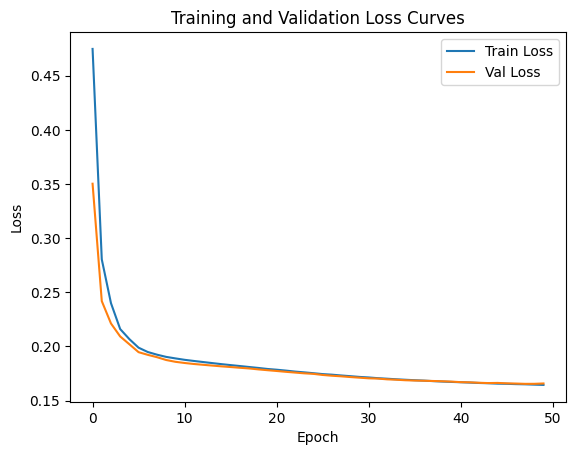

In [ ]:
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.show()

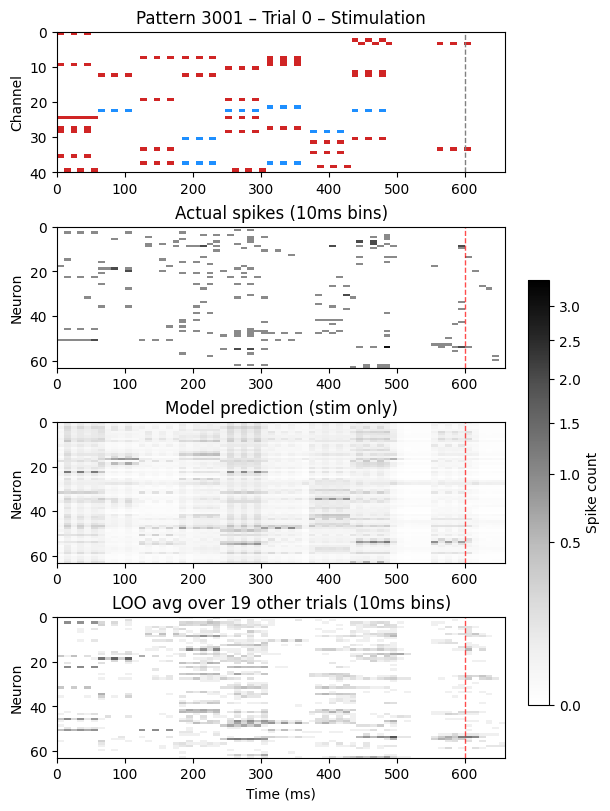

In [ ]:
# ============================================================
# Visualize one trained CNN test example (oracle pattern), reusing
# patterns_5k/viz.py:plot_single_oracle_trial.
#
# Panels: stim polarity, actual spikes, model prediction, LOO trial average.
# ============================================================
import numpy as np
import torch
from viz import plot_single_oracle_trial

# Build the cfg + raw_data dicts the viz function expects.
cfg = dict(
    input_bin_size_ms  = CFG['INPUT_BIN_MS'],
    output_bin_size_ms = CFG['OUTPUT_BIN_MS'],
    n_input_bins       = CFG['N_INPUT_BINS'],
    n_output_bins      = CFG['N_OUTPUT_BINS'],
    max_time_ms        = CFG['MAX_TIME_MS'],
    output_offset      = 0,
    history            = 0,
    init_state         = False,
    encoding_mode      = CFG['ENCODING_MODE'],
)
raw_data = dict(
    pattern_df         = pattern_df,
    spike_responses    = spike_responses,
    pattern_polarities = pattern_polarities,
)
model_tuple = (model, base_criterion, device)

# Pick the first oracle pattern with at least 2 trials so LOO is meaningful.
unique_oracle = pattern_df[pattern_df['is_oracle']][['pattern_name', 'pattern_timing_index']].drop_duplicates()
counts = unique_oracle.groupby('pattern_name').size()
PATTERN_TO_SHOW = counts[counts >= 2].index[0] if (counts >= 2).any() else counts.index[0]
TRIAL_IDX = 0

fig = plot_single_oracle_trial(
    pattern_name=PATTERN_TO_SHOW,
    trial_idx=TRIAL_IDX,
    model_tuple=model_tuple,
    cfg=cfg,
    raw_data=raw_data,
    test_loader=test_loader,
    coarse_factor=1,
)

from IPython.display import display
fig.axes[2].set_title(f'Model prediction (stim only)')
display(fig)


### Greedy pattern `StimCreator`

Same `StimCreator` class and instantiation pattern as `greedy_pattern_gen_6_1_26.ipynb`; it consumes the loaded `model`, `device`, `channel_to_index`, and `proj` when generating `est_stims`.


In [ ]:
import heapq
import numpy as np
import torch


class StimCreator():
    """Greedy stim builder. Each 60 ms step (= 6 bins of 10 ms) can hold up to
    `budget_per_step` simultaneously-active channels; for each slot we try every
    (channel, encoding) candidate and keep the one whose model prediction has the
    smallest L2 distance to `target_spikes`.

    Hardware constraint enforced during the search: channels are partitioned
    into `n_shanks` equal-sized shanks by sorted channel ID, and at most
    `max_per_shank` channels per shank may fire SIMULTANEOUSLY (same bin within
    a step). Two channels with non-overlapping delay_mode bin-sets (e.g.
    dm=0 fires bins {0,2,4} vs dm=1 fires bins {1,3,5}) don't conflict.

    Encoding -> (offsets within the 6-bin step, amplitude) follows
    encode_pattern_nominal_current_10ms in patterns_5k/utils.py:
        delay_mode  0 -> bins {0,2,4}, +3
        delay_mode -1 -> bins {0,2,4}, -3
        delay_mode  1 -> bins {1,3,5}, +3
        delay_mode  2 -> bins {0..5},  +3
    """

    BINS_PER_STEP = 6  # 60 ms / 10 ms

    _ENCODING_TABLE = {
         0: ([0, 2, 4],            3), # 
        -1: ([0, 2, 4],           -3),
         1: ([1, 3, 5],           3),
         2: ([0, 1, 2, 3, 4, 5],   3),
    }

    def __init__(self, model, device, channel_to_index, n_bins,
                 n_shanks=4, max_per_shank=4, proj=None):
        self.model = model.to(device)
        self.model.eval()
        self.device = device
        self.channel_to_index = channel_to_index
        self.n_stim_channels = len(channel_to_index)
        self.n_bins = n_bins  # total 10 ms bins in the stim window

        # Shank partition: equal-sized chunks of sorted channel IDs.
        # Map ch_index (the row in the stim array) -> shank id.
        sorted_chs = sorted(channel_to_index.keys())
        if len(sorted_chs) % n_shanks != 0:
            raise ValueError(f"cannot split {len(sorted_chs)} channels into "
                             f"{n_shanks} equal shanks")
        shank_size = len(sorted_chs) // n_shanks
        ch_to_shank_by_id = {ch: i // shank_size
                             for i, ch in enumerate(sorted_chs)}
        # channel_to_index maps channel-id -> row in stim array; invert.
        self._idx_to_shank = np.empty(self.n_stim_channels, dtype=np.int64)
        for ch_id, idx in channel_to_index.items():
            self._idx_to_shank[idx] = ch_to_shank_by_id[ch_id]
        self.n_shanks = n_shanks
        self.max_per_shank = max_per_shank

        # Precompute bin-set per encoding.
        self._enc_bins = {enc: tuple(offsets)
                          for enc, (offsets, _amp) in self._ENCODING_TABLE.items()}
        
        # Projection for distance calculation: if provided, distance is measured in the projected space.
        if proj is not None:
            self.proj = proj
        else:
            self.proj = np.eye(n_neurons, dtype=np.float32)

    def stim_sequence_from_encoding(self, encoding):
        """Return a length-6 vector for one 60 ms step at 10 ms resolution."""
        seq = np.zeros(self.BINS_PER_STEP, dtype=np.float32)
        if encoding in self._ENCODING_TABLE:
            offsets, amp = self._ENCODING_TABLE[encoding]
            for o in offsets:
                seq[o] = amp
        return seq

    def _predict(self, stim, n_bins_truncate=None):
        """stim: (n_stim_channels, n_bins) -> (n_neurons, n_bins) numpy."""
        x = torch.from_numpy(stim).unsqueeze(0).to(self.device).float()
        with torch.no_grad():
            pred = self.model(x)
        if n_bins_truncate is not None:
            pred = pred[:, :, :n_bins_truncate]
        return torch.exp(pred).cpu().numpy()[0]

    def create_stim(self, target_spikes, budget_per_step=2,
                    encodings=(-1, 0, 1, 2), channels=None,
                    require_improvement=True, verbose=False):
        """Greedily build a stim driving the model toward `target_spikes`.

        Args:
            target_spikes: (n_neurons, n_bins) target.
            budget_per_step: max channels stimulated per 60 ms step.
            encodings: encoding labels to consider per slot.
            channels: stim-channel indices to consider (default: all).
            require_improvement: if True, stop filling a step's budget once no
                candidate strictly reduces distance.

        Returns:
            created_stim: (n_stim_channels, n_bins) float32.
            final_dist:   final L2 distance of model prediction to target.
        """
        if channels is None:
            channels = list(range(self.n_stim_channels))
        else:
            channels = list(channels)

        n_steps = self.n_bins // self.BINS_PER_STEP
        created_stim = np.zeros((self.n_stim_channels, self.n_bins), dtype=np.float32)
        used_channels_per_step = [set() for _ in range(n_steps)]
        # Per-step (shank, bin)-occupancy: shank_bin_count[step][shank, bin].
        shank_bin_count = [
            np.zeros((self.n_shanks, self.BINS_PER_STEP), dtype=np.int32)
            for _ in range(n_steps)
        ]
        curr_dist = np.linalg.norm(self._predict(created_stim, n_bins_truncate=self.n_bins).sum(axis=1) @ self.proj - target_spikes @ self.proj)
        self.last_distance_history = [float(curr_dist)]          # baseline + accepted greedy updates
        self.last_distance_step_history = [float(curr_dist)]     # baseline + after each 60 ms step
        self.last_distance_update_steps = [0]                    # outer step index for each accepted update
        if verbose:
            print(f"baseline dist: {curr_dist:.4f}")

        # Precompute encoding sequences.
        enc_seqs = [(e, self.stim_sequence_from_encoding(e)) for e in encodings]

        for step in range(n_steps):
            t0 = step * self.BINS_PER_STEP
            t1 = t0 + self.BINS_PER_STEP
            occ = shank_bin_count[step]

            for _ in range(budget_per_step):
                # Initialize best to the "add nothing this slot" option: the
                # distance of the stim as it currently stands (ch/enc/seq=None).
                # A real candidate is only chosen if it beats doing nothing.
                best = (curr_dist, None, None, None)  # (dist, ch, enc, seq)
                for ch in channels:
                    if ch in used_channels_per_step[step]:
                        continue
                    shank = self._idx_to_shank[ch]
                    for enc, seq in enc_seqs:
                        # Reject any candidate that would push a (shank, bin)
                        # cell above max_per_shank for this step.
                        bins_used = self._enc_bins[enc]
                        if any(occ[shank, b] + 1 > self.max_per_shank
                               for b in bins_used):
                            continue
                        cand = created_stim.copy()
                        cand[ch, t0:t1] = seq
                        d = np.linalg.norm(self._predict(cand, n_bins_truncate=self.n_bins).sum(axis=1) @ self.proj - target_spikes @ self.proj)
                        if d < best[0]: # greedy: must beat current best (incl. do-nothing)
                            best = (d, ch, enc, seq)

                # If the best option is to add nothing (no candidate beat the
                # do-nothing distance), stop filling this step's budget.
                if best[1] is None:
                    break
                if require_improvement and best[0] >= curr_dist:
                    break

                d, ch, enc, seq = best
                created_stim[ch, t0:t1] = seq
                used_channels_per_step[step].add(ch)
                # Commit the bin occupancy for the chosen channel/encoding.
                shank = self._idx_to_shank[ch]
                for b in self._enc_bins[enc]:
                    occ[shank, b] += 1
                curr_dist = d
                self.last_distance_history.append(float(curr_dist))
                self.last_distance_update_steps.append(step + 1)
                if verbose:
                    print(f"  step {step}: ch={ch}, enc={enc:>2}, dist={d:.4f}")

            self.last_distance_step_history.append(float(curr_dist))

        return created_stim, curr_dist


In [45]:
VIS_ORIENT_TIME = 600  # ms window for visual orientation decoding (from above analysis)
BUDGET = 4

if VIS_ORIENT_TIME > STIM_MS: 
    fac = VIS_ORIENT_TIME / STIM_MS
else:
    fac = 1
targets = sum_responses[:, :, :VIS_ORIENT_TIME // 10].sum(axis=2) * fac  # (n_orientations, n_neurons, n_bins) -> (n_orientations, n_neurons, 12) bc 10 ms bins scaled
est_stims = []
distances = []
distance_histories = []
distance_step_histories = []
distance_update_steps = []
for o_idx, orientation in enumerate(visual_orientation_degs):
    target_spikes = targets[o_idx]  # (n_neurons,)
    stim_creator = StimCreator(model, device, channel_to_index, n_bins=VIS_ORIENT_TIME // 10, proj=proj)
    created_stim, final_dist = stim_creator.create_stim(
        target_spikes=target_spikes,
        budget_per_step=BUDGET,
        encodings=[-1, 0, 1, 2],
        channels=None,
        require_improvement=True,
        verbose=True,
    )
    est_stims.append(created_stim)
    distances.append(final_dist)
    distance_histories.append(np.array(stim_creator.last_distance_history, dtype=float))
    distance_step_histories.append(np.array(stim_creator.last_distance_step_history, dtype=float))
    distance_update_steps.append(np.array(stim_creator.last_distance_update_steps, dtype=int))
    print(f"Orientation {orientation}°: final dist={final_dist:.4f}")


baseline dist: 46.1593
  step 0: ch=30, enc= 2, dist=39.0574
  step 0: ch=26, enc= 2, dist=35.6698
  step 0: ch=31, enc=-1, dist=32.8010
  step 0: ch=13, enc=-1, dist=32.0666
  step 1: ch=30, enc= 2, dist=25.1355
  step 1: ch=26, enc= 2, dist=22.2202
  step 1: ch=31, enc=-1, dist=19.4297
  step 1: ch=13, enc=-1, dist=18.8566
  step 2: ch=30, enc= 2, dist=12.0395
  step 2: ch=26, enc= 2, dist=9.1335
  step 2: ch=31, enc=-1, dist=6.4707
  step 2: ch=13, enc=-1, dist=5.9309
  step 3: ch=26, enc= 2, dist=2.1706
  step 3: ch=10, enc= 1, dist=1.9082
  step 3: ch=23, enc=-1, dist=1.7094
  step 3: ch=2, enc= 0, dist=1.6618
  step 4: ch=9, enc= 2, dist=1.5196
  step 4: ch=39, enc= 0, dist=1.3787
  step 4: ch=23, enc=-1, dist=1.3477
  step 4: ch=15, enc= 1, dist=1.3354
  step 5: ch=15, enc= 2, dist=1.2198
  step 5: ch=6, enc= 2, dist=1.2054
  step 5: ch=5, enc=-1, dist=1.1939
  step 6: ch=15, enc= 2, dist=1.0838
  step 6: ch=6, enc= 2, dist=1.0689
  step 6: ch=5, enc=-1, dist=1.0600
  step 7: ch

### Greedy optimization loss trajectory

Distance to the visual target is recorded during `StimCreator.create_stim` so we can inspect how the greedy search improves as more 60 ms optimization steps are added.


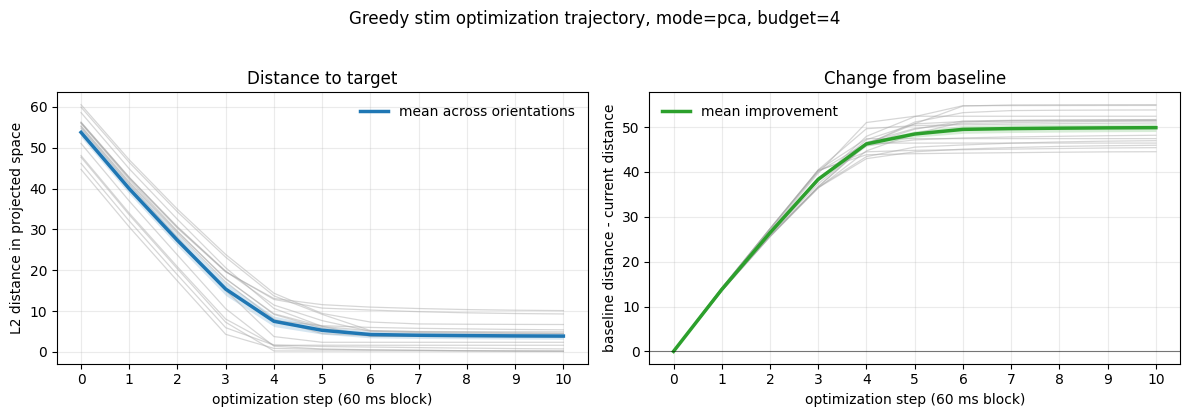

In [46]:
# Distance-to-target over greedy optimization steps.
# Requires running the `est_stims` generation cell above so `distance_step_histories`
# is populated with one trace per target orientation.
import numpy as np
import matplotlib.pyplot as plt

if 'distance_step_histories' not in globals() or len(distance_step_histories) == 0:
    raise RuntimeError('Run the greedy stim generation cell first to populate distance_step_histories.')

step_mat = np.vstack(distance_step_histories)  # (n_orient, n_steps + 1), includes baseline at step 0
steps = np.arange(step_mat.shape[1])
mean_dist = step_mat.mean(axis=0)
sem_dist = step_mat.std(axis=0, ddof=1) / np.sqrt(step_mat.shape[0]) if step_mat.shape[0] > 1 else np.zeros_like(mean_dist)

loss_drop = step_mat[:, [0]] - step_mat
mean_drop = loss_drop.mean(axis=0)
sem_drop = loss_drop.std(axis=0, ddof=1) / np.sqrt(loss_drop.shape[0]) if loss_drop.shape[0] > 1 else np.zeros_like(mean_drop)

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for o_idx, deg in enumerate(visual_orientation_degs):
    ax[0].plot(steps, step_mat[o_idx], color='0.65', lw=0.9, alpha=0.45)
    ax[1].plot(steps, loss_drop[o_idx], color='0.65', lw=0.9, alpha=0.45)

ax[0].plot(steps, mean_dist, color='tab:blue', lw=2.5, label='mean across orientations')
ax[0].fill_between(steps, mean_dist - sem_dist, mean_dist + sem_dist,
                   color='tab:blue', alpha=0.18, linewidth=0)
ax[0].set_title('Distance to target')
ax[0].set_ylabel('L2 distance in projected space')
ax[0].legend(frameon=False)

ax[1].plot(steps, mean_drop, color='tab:green', lw=2.5, label='mean improvement')
ax[1].fill_between(steps, mean_drop - sem_drop, mean_drop + sem_drop,
                   color='tab:green', alpha=0.18, linewidth=0)
ax[1].axhline(0, color='black', lw=0.8, alpha=0.5)
ax[1].set_title('Change from baseline')
ax[1].set_ylabel('baseline distance - current distance')
ax[1].legend(frameon=False)

for a in ax:
    a.set_xlabel('optimization step (60 ms block)')
    a.grid(True, alpha=0.25)
    a.set_xticks(steps)

fig.suptitle(f'Greedy stim optimization trajectory, mode={mode}, budget={BUDGET}', y=1.03)
fig.tight_layout()
plt.savefig(f'../../results/greedy_stim_budget{BUDGET}_distance_by_step_{mode}.png', dpi=300, bbox_inches='tight')
plt.show()
